# 04 — Machine Learning Analysis

## Australian Energy Market Analytics

The earlier notebooks established clear temporal patterns in electricity demand and Regional Reference Price (RRP), together with a positive demand–price relationship and distinct behaviour during positive price spikes and negative-price periods.

This notebook extends the project from **descriptive and statistical analysis** into **predictive modelling**.

### Machine-learning objectives

1. **Regression:** predict continuous electricity spot prices (`RRP`) from demand and temporal features.
2. **Classification:** predict whether a five-minute interval is likely to experience an unusually high price spike.
3. Compare simple and nonlinear models using appropriate evaluation metrics.
4. Examine feature importance to identify which available variables contribute most to prediction.

> **Important:** The models are exploratory. They use only demand and time-based variables and therefore do not represent a production electricity-price forecasting system. Generator availability, renewable output, network constraints, interconnector flows, weather and bidding behaviour are not included in the dataset.

## 1. Setup and Data Loading

The cleaned dataset from the previous stages is loaded and ordered chronologically. Keeping the observations in time order is important because the model should be evaluated on later observations that were not used during training.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

RANDOM_STATE = 42

In [49]:
# Load the csv 
df = pd.read_csv(
    "../data/processed/clean_price_demand.csv",
    parse_dates=["SETTLEMENTDATE"]
)

df = df.sort_values("SETTLEMENTDATE").reset_index(drop=True)

df.head()

,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,NSW1,2026-08-01 00:05:00,8898.91,89.88,TRADE
1,NSW1,2026-08-01 00:10:00,9032.33,95.05,TRADE
2,NSW1,2026-08-01 00:15:00,8989.12,88.88,TRADE
3,NSW1,2026-08-01 00:20:00,9036.72,88.88,TRADE
4,NSW1,2026-08-01 00:25:00,8946.67,84.79,TRADE


In [50]:
print(f"Observations: {len(df):,}")
print(f"Date range: {df['SETTLEMENTDATE'].min()} to {df['SETTLEMENTDATE'].max()}")
print("Missing values: ")
print(df[["SETTLEMENTDATE", "TOTALDEMAND", "RRP"]].isna().sum())

Observations: 7,776
Date range: 2026-08-01 00:05:00 to 2026-08-28 00:00:00
Missing values: 
SETTLEMENTDATE    0
TOTALDEMAND       0
RRP               0
dtype: int64


## 2. Feature Engineering

The existing analysis showed that both **demand** and **time of day** are associated with spot-price behaviour. These variables are therefore used as the initial predictors.

Hour and day-of-week are cyclical variables: 23:00 is close to 00:00, and Sunday is close to Monday. Sine and cosine transformations preserve this cyclical structure more naturally than treating these variables as ordinary integers.

In [51]:
df["hour"] = df["SETTLEMENTDATE"].dt.hour
df["day_of_week"] = df["SETTLEMENTDATE"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Cyclical encoding for hour of day
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Cyclical encoding for day of week
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

features = [
    "TOTALDEMAND",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "is_weekend"
]

df[features].head()

,TOTALDEMAND,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend
0,8898.91,0.0,1.0,-0.974928,-0.222521,1
1,9032.33,0.0,1.0,-0.974928,-0.222521,1
2,8989.12,0.0,1.0,-0.974928,-0.222521,1
3,9036.72,0.0,1.0,-0.974928,-0.222521,1
4,8946.67,0.0,1.0,-0.974928,-0.222521,1


### Why these features?

- `TOTALDEMAND` captures the system-demand conditions that were strongly associated with RRP in the previous notebook.
- `hour_sin` and `hour_cos` capture recurring intraday patterns without creating an artificial gap between 23:00 and 00:00.
- `dow_sin`, `dow_cos`, and `is_weekend` represent weekly and weekday/weekend structure.

These features intentionally remain simple so that model performance can be interpreted as the predictive value of **demand and timing alone**.

## 3. Chronological Train-Test Split

A random train–test split is avoided because neighbouring five-minute electricity-market observations are strongly related through time. Randomly mixing early and late observations could produce an unrealistically easy evaluation.

The first **80%** of observations are used for training and the final **20%** are reserved for testing.

In [52]:
split_index = int(len(df) * 0.80)

train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

print(f"Training observations: {len(train):,}")
print(f"Testing observations:  {len(test):,}")
print(f"Training period: {train['SETTLEMENTDATE'].min()} to {train['SETTLEMENTDATE'].max()}")
print(f"Testing period:  {test['SETTLEMENTDATE'].min()} to {test['SETTLEMENTDATE'].max()}")

Training observations: 6,220
Testing observations:  1,556
Training period: 2026-08-01 00:05:00 to 2026-08-22 14:20:00
Testing period:  2026-08-22 14:25:00 to 2026-08-28 00:00:00


# Part A — Spot Price Regression

## 4. Regression Objective

The first machine-learning task predicts the continuous Regional Reference Price (`RRP`). Three models are compared with a naive baseline:

- Mean-price baseline
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Performance is evaluated using **MAE**, **RMSE**, and **R²**.

- **MAE** measures the average absolute prediction error.
- **RMSE** penalises large errors more strongly and is useful when price spikes are important.
- **R²** measures how much variation in the test-set RRP is explained by the model relative to predicting the test mean.

In [53]:
X_train = train[features]
X_test = test[features]
y_train = train["RRP"]
y_test = test["RRP"]

### 4.1 Naive Baseline

Before evaluating machine-learning models, a baseline is created that predicts the **training-set mean RRP** for every test observation. A useful predictive model should outperform this benchmark.

In [54]:
baseline_pred = np.full(len(y_test), y_train.mean())

def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²": r2_score(y_true, y_pred)
    }

baseline_metrics = regression_metrics(y_test, baseline_pred)
baseline_metrics

{'MAE': 36.146708265484094,
 'RMSE': np.float64(45.85728941553226),
 'R²': -0.06972348132597439}

### 4.2 Linear Regression

Linear Regression provides an interpretable benchmark and extends the earlier one-variable demand–price regression by including temporal features.

In [43]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

linear_metrics = regression_metrics(y_test, linear_pred)
linear_metrics

{'MAE': 30.597857202742187,
 'RMSE': np.float64(39.03360644660604),
 'R²': 0.22494570654787194}

### 4.3 Decision Tree Regressor

A Decision Tree can capture nonlinear relationships and interactions that Linear Regression may miss. Tree depth is restricted to reduce overfitting.

In [55]:
tree_model = DecisionTreeRegressor(
    max_depth=6,
    min_samples_leaf=20,
    random_state=RANDOM_STATE
)

tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

tree_metrics = regression_metrics(y_test, tree_pred)
tree_metrics

{'MAE': 28.66149332599514,
 'RMSE': np.float64(38.93549533670145),
 'R²': 0.2288370134840333}

### 4.4 Random Forest Regressor

Random Forest averages many decision trees, allowing it to model nonlinear relationships while generally being more stable than a single tree.

In [56]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_metrics = regression_metrics(y_test, rf_pred)
rf_metrics

{'MAE': 31.760648626866733,
 'RMSE': np.float64(41.51591422409945),
 'R²': 0.1232334342724225}

In [57]:
regression_results = pd.DataFrame([
    {"Model": "Mean Baseline", **baseline_metrics},
    {"Model": "Linear Regression", **linear_metrics},
    {"Model": "Decision Tree", **tree_metrics},
    {"Model": "Random Forest", **rf_metrics}
]).set_index("Model")

regression_results.round(3)

,MAE,RMSE,R²
Model,,,
Mean Baseline,36.147,45.857,-0.070
Linear Regression,30.598,39.034,0.225
Decision Tree,28.661,38.935,0.229
Random Forest,31.761,41.516,0.123


## 5. Regression Model Comparison

The models are compared using the same held-out chronological test set. Lower MAE and RMSE indicate smaller prediction errors, while a higher R² indicates stronger explanatory performance on unseen data.

In [58]:
regression_results = pd.DataFrame([
    {"Model": "Mean Baseline", **baseline_metrics},
    {"Model": "Linear Regression", **linear_metrics},
    {"Model": "Decision Tree", **tree_metrics},
    {"Model": "Random Forest", **rf_metrics}
]).set_index("Model")

regression_results.round(3)

,MAE,RMSE,R²
Model,,,
Mean Baseline,36.147,45.857,-0.070
Linear Regression,30.598,39.034,0.225
Decision Tree,28.661,38.935,0.229
Random Forest,31.761,41.516,0.123


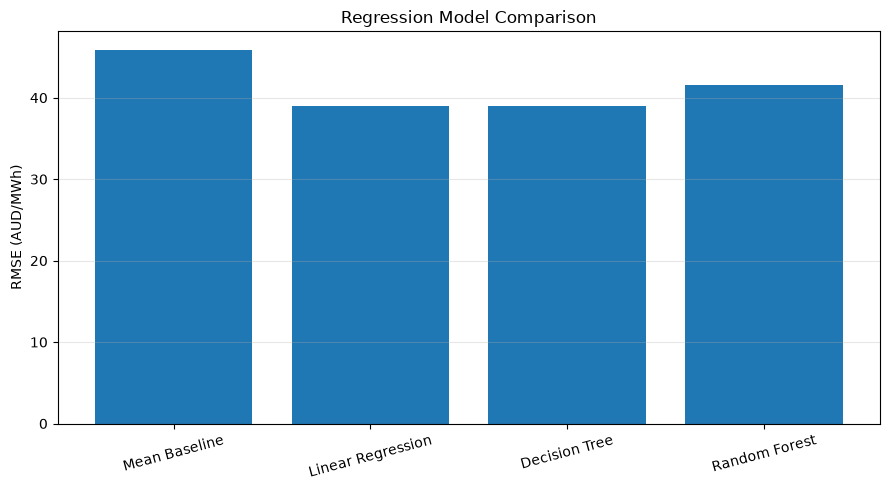

In [59]:
plt.figure(figsize=(9, 5))
plt.bar(regression_results.index, regression_results["RMSE"])
plt.ylabel("RMSE (AUD/MWh)")
plt.title("Regression Model Comparison")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

All three machine-learning models outperform the mean baseline, indicating that
electricity demand and temporal features contain useful information for predicting
spot prices.

The **Decision Tree achieved the strongest overall performance**, with an MAE of
approximately **AUD 28.66/MWh**, RMSE of **AUD 38.94/MWh**, and an R² of **0.229**.
This represents an approximately **15.1% reduction in RMSE** relative to the mean
baseline.

Linear Regression performed similarly, achieving an R² of **0.225**, while the
Random Forest produced a lower R² of **0.123**. The limited improvement of the
non-linear models suggests that increasing model complexity alone does not
substantially improve prediction using the current feature set.

The relatively modest R² values also indicate that electricity demand and
time-related variables explain only part of the variation in spot prices. Other
market factors, such as renewable generation, generator availability, network
constraints, bidding behaviour and previous market conditions, may contribute
substantially to short-term price movements.

The difference between MAE and RMSE further suggests that some observations
produce relatively large prediction errors. This is consistent with the earlier
exploratory analysis, which identified occasional extreme price-spike events that
are considerably more difficult to predict than normal market conditions.

## 6. Actual vs Predicted Spot Prices

A time-ordered comparison of actual and predicted RRP helps reveal whether the best-performing model follows normal price movements and whether it systematically underpredicts sudden extreme events.

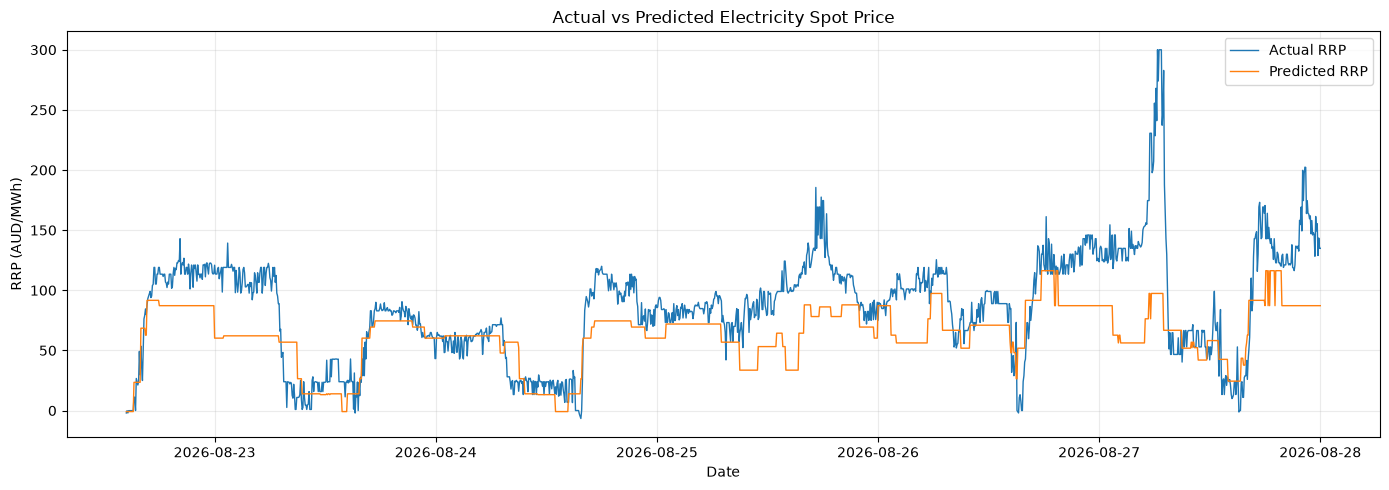

In [64]:
# Change this to the best-performing model if another model wins.
best_reg_pred = tree_pred

plt.figure(figsize=(14, 5))
plt.plot(test["SETTLEMENTDATE"], y_test.values, label="Actual RRP", linewidth=1)
plt.plot(test["SETTLEMENTDATE"], best_reg_pred, label="Predicted RRP", linewidth=1)
plt.xlabel("Date")
plt.ylabel("RRP (AUD/MWh)")
plt.title("Actual vs Predicted Electricity Spot Price")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Intepretation

The figure compares actual electricity spot prices with predictions from the
Decision Tree, which achieved the strongest overall performance among the
regression models evaluated.

The model captures the broad movement of electricity prices, with predicted
prices generally increasing and decreasing in the same periods as the observed
RRP. However, the predictions are noticeably smoother and more step-like than
the actual price series, which is characteristic of Decision Tree regression.

The largest prediction errors occur during periods of extreme price volatility.
Most notably, when the actual RRP rises towards approximately AUD 300/MWh, the
model substantially underpredicts the magnitude of the spike. This indicates
that the available predictors are sufficient to identify some general price
patterns but are less effective at explaining sudden extreme-price events.

This behaviour is consistent with the Decision Tree's test performance
(R² = 0.229, MAE = 28.661 AUD/MWh and RMSE = 38.935 AUD/MWh). The model therefore
provides useful predictive information beyond the baseline, but a substantial
proportion of short-term electricity-price variation remains unexplained.

# Part B — Price-Spike Classification

## 7. Classification Objective

The second machine-learning task predicts whether an interval experiences an unusually high electricity price.

A price spike is defined using the **95th percentile of RRP in the training data only**. Using the training data to determine the threshold avoids leaking information from the future test period into model construction.

The target is binary:

- `0` — normal price
- `1` — price spike

In [65]:
# Define the spike threshold using TRAINING data only to avoid test-set leakage.
spike_threshold = train["RRP"].quantile(0.95)

train["price_spike"] = (train["RRP"] > spike_threshold).astype(int)
test["price_spike"] = (test["RRP"] > spike_threshold).astype(int)

print(f"Training-based 95th percentile threshold: {spike_threshold:.2f} AUD/MWh")
print("Training class distribution (%):")
print(train["price_spike"].value_counts(normalize=True).mul(100).round(2).sort_index())
print("Test class distribution (%):")
print(test["price_spike"].value_counts(normalize=True).mul(100).round(2).sort_index())

Training-based 95th percentile threshold: 130.01 AUD/MWh
Training class distribution (%):
price_spike
0    95.03
1     4.97
Name: proportion, dtype: float64
Test class distribution (%):
price_spike
0    88.56
1    11.44
Name: proportion, dtype: float64


### Class imbalance

Price spikes represent only a small proportion of intervals. Therefore, **accuracy alone is not an appropriate evaluation metric**: a model that predicts “normal price” almost every time could achieve high accuracy while failing to identify the events of greatest interest.

The analysis therefore focuses on:

- **Precision** — among predicted spikes, how many were actually spikes?
- **Recall** — among actual spikes, how many did the model detect?
- **F1-score** — harmonic mean of precision and recall.
- **ROC-AUC** — ability to rank spike observations above normal observations across classification thresholds.

In [66]:
X_train_cls = train[features]
X_test_cls = test[features]
y_train_cls = train["price_spike"]
y_test_cls = test["price_spike"]

def classification_metrics(y_true, y_pred, y_prob):
    return {
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

### 7.1 Logistic Regression

Logistic Regression provides a simple and interpretable classification baseline. `class_weight="balanced"` gives greater weight to the minority spike class during model fitting.

In [67]:
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE
)

log_model.fit(X_train_cls, y_train_cls)
log_pred = log_model.predict(X_test_cls)
log_prob = log_model.predict_proba(X_test_cls)[:, 1]

log_metrics = classification_metrics(y_test_cls, log_pred, log_prob)
log_metrics

{'Precision': 0.4666666666666667,
 'Recall': 0.39325842696629215,
 'F1': 0.4268292682926829,
 'ROC-AUC': 0.8986358669949936}

### 7.2 Decision Tree Classifier

The Decision Tree allows nonlinear threshold behaviour, such as a sharp increase in spike risk once demand becomes sufficiently high.

In [68]:
tree_cls = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

tree_cls.fit(X_train_cls, y_train_cls)
tree_cls_pred = tree_cls.predict(X_test_cls)
tree_cls_prob = tree_cls.predict_proba(X_test_cls)[:, 1]

tree_cls_metrics = classification_metrics(y_test_cls, tree_cls_pred, tree_cls_prob)
tree_cls_metrics

{'Precision': 0.39634146341463417,
 'Recall': 0.3651685393258427,
 'F1': 0.38011695906432746,
 'ROC-AUC': 0.6453233802449406}

### 7.3 Random Forest Classifier

Random Forest combines many trees and can capture nonlinear relationships between demand, time and spike probability while reducing the instability of a single decision tree.

In [69]:
rf_cls = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_cls.fit(X_train_cls, y_train_cls)
rf_cls_pred = rf_cls.predict(X_test_cls)
rf_cls_prob = rf_cls.predict_proba(X_test_cls)[:, 1]

rf_cls_metrics = classification_metrics(y_test_cls, rf_cls_pred, rf_cls_prob)
rf_cls_metrics

{'Precision': 0.463768115942029,
 'Recall': 0.1797752808988764,
 'F1': 0.2591093117408907,
 'ROC-AUC': 0.8832435054875165}

## 8. Classification Model Comparison

Because spike events are rare, the best model should not be selected by accuracy alone. In an electricity-market monitoring context, **recall** may be particularly important because missing a true price spike can be more consequential than generating some false alerts.

In [70]:
classification_results = pd.DataFrame([
    {"Model": "Logistic Regression", **log_metrics},
    {"Model": "Decision Tree", **tree_cls_metrics},
    {"Model": "Random Forest", **rf_cls_metrics}
]).set_index("Model")

classification_results.round(3)

,Precision,Recall,F1,ROC-AUC
Model,,,,
Logistic Regression,0.467,0.393,0.427,0.899
Decision Tree,0.396,0.365,0.380,0.645
Random Forest,0.464,0.180,0.259,0.883


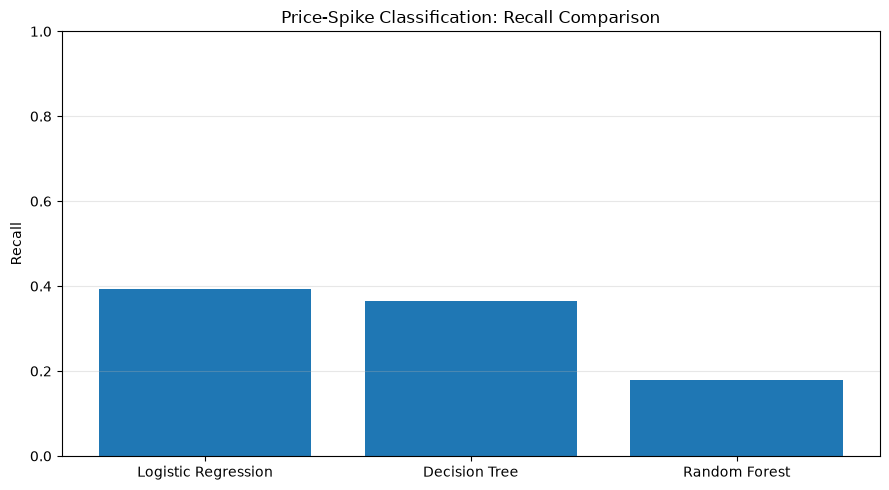

In [71]:
plt.figure(figsize=(9, 5))
plt.bar(classification_results.index, classification_results["Recall"])
plt.ylabel("Recall")
plt.title("Price-Spike Classification: Recall Comparison")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Intepretation

The classification models were evaluated using precision, recall, F1-score
and ROC-AUC, with price-spike intervals treated as the positive class.

Logistic Regression achieved the strongest overall classification performance,
with a precision of 0.467, recall of 0.393, F1-score of 0.427 and ROC-AUC of
0.899. At the default classification threshold, the model therefore identifies
approximately 39.3% of actual price-spike intervals, while approximately 46.7%
of the intervals predicted as spikes are true spikes.

The Decision Tree achieved slightly lower recall (0.365) and F1-score (0.380),
while its substantially lower ROC-AUC of 0.645 indicates weaker overall
separation between spike and non-spike observations.

The Random Forest achieved a relatively high ROC-AUC of 0.883 but considerably
lower recall of 0.180. This suggests that although the model can rank higher-risk
observations reasonably well, its predictions at the default classification
threshold are conservative and miss a large proportion of actual price spikes.

Overall, **Logistic Regression** provides the strongest balance between detecting
price spikes and limiting false-positive predictions among the models tested.
However, its recall remains below 0.40, indicating that further improvements
such as class weighting, threshold tuning and additional predictive features
may be required for effective price-spike detection.

## 9. Confusion Matrix for Logistic Regression Classifier

The confusion matrix separates correct and incorrect predictions into normal-price and price-spike outcomes, making model errors easier to interpret than a single metric.

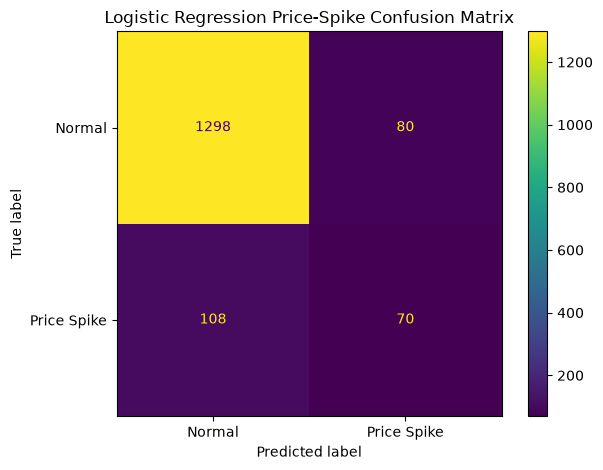

              precision    recall  f1-score   support

      Normal       0.92      0.94      0.93      1378
 Price Spike       0.47      0.39      0.43       178

    accuracy                           0.88      1556
   macro avg       0.69      0.67      0.68      1556
weighted avg       0.87      0.88      0.87      1556



In [83]:
ConfusionMatrixDisplay.from_predictions(
    y_test_cls,
    log_pred,
    display_labels=["Normal", "Price Spike"],
    values_format="d"
)
plt.title("Logistic Regression Price-Spike Confusion Matrix")
plt.tight_layout()
plt.show()

print(classification_report(
    y_test_cls,
    log_pred,
    target_names=["Normal", "Price Spike"],
    zero_division=0
))

### Interpretation

The Logistic Regression model correctly classified 1,298 normal-price intervals and successfully detected 70 price-spike intervals. However, it produced 80 false-positive spike alerts and failed to detect 108 actual price spikes.

For the price-spike class, the model achieved a precision of 0.47, meaning that approximately 47% of predicted price spikes were actual spikes. Recall was 0.39, indicating that the model detected approximately 39% of all price-spike events, while the remaining 61% were missed. The resulting F1-score of 0.43 reflects the difficulty of balancing spike detection with false alarms.

Although the model achieved an overall accuracy of 88%, this result should be interpreted cautiously because the test dataset is highly imbalanced, containing 1,378 normal observations compared with only 178 price-spike observations. Consequently, accuracy is dominated by the model's strong performance on the majority normal-price class.

Combined with the relatively high ROC-AUC of approximately 0.90, these results suggest that Logistic Regression has good ability to distinguish higher-risk from lower-risk observations across classification thresholds, but its performance at the default 0.50 threshold remains limited for detecting the minority price-spike class. Adjusting the classification threshold could therefore be explored to increase spike recall, with the trade-off of generating more false-positive alerts.

## 10. ROC Curve

The ROC curve evaluates classification performance across probability thresholds rather than relying only on the default 0.50 threshold.

<Figure size 700x600 with 0 Axes>

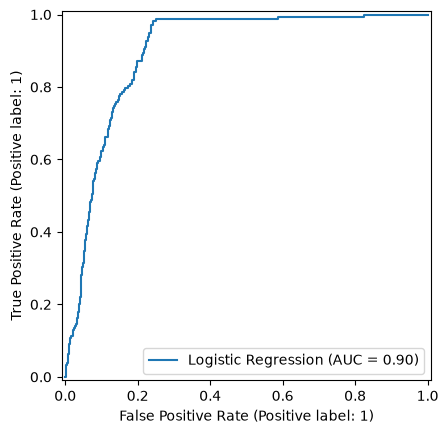

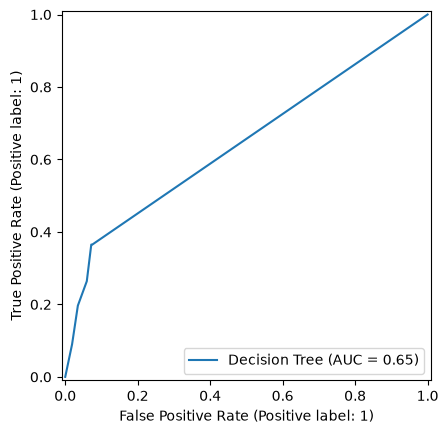

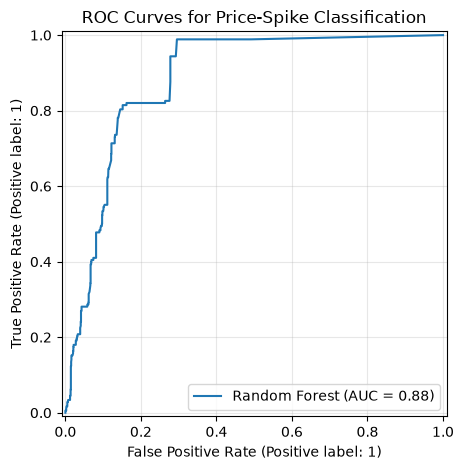

In [74]:
plt.figure(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test_cls, log_prob, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test_cls, tree_cls_prob, name="Decision Tree")
RocCurveDisplay.from_predictions(y_test_cls, rf_cls_prob, name="Random Forest")
plt.title("ROC Curves for Price-Spike Classification")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The ROC curves evaluate each classifier's ability to distinguish price-spike
intervals from normal-price intervals across a range of probability thresholds.

Logistic Regression achieves the strongest discrimination, with an ROC-AUC of
approximately 0.90. Random Forest also performs strongly with an ROC-AUC of
approximately 0.88, while the Decision Tree achieves a considerably lower
ROC-AUC of approximately 0.65.

These results suggest that Logistic Regression and Random Forest contain useful
predictive information for distinguishing high-risk price-spike conditions.
The relatively high ROC-AUC values are particularly important because the
recall obtained using the default classification threshold remains modest.
This suggests that adjusting the probability threshold could potentially
increase the proportion of price spikes detected, although this would involve
a trade-off with a higher false-positive rate.

## 11. Logistic Regression Feature Effects

Logistic Regression achieved the strongest overall classification performance, so its fitted coefficients are examined to understand which predictors are most strongly associated with price-spike predictions.

Unlike tree-based models, Logistic Regression does not provide `feature_importances_`. Instead, each feature has a coefficient describing how changes in that feature affect the model's predicted log-odds of a price spike.

A positive coefficient is associated with a higher predicted probability of a price spike, while a negative coefficient is associated with a lower predicted probability, holding the other predictors constant.

Because coefficient magnitude depends on the scale of the predictors, standardized coefficients are preferable when comparing the relative influence of different features.

In [81]:
feature_std = X_train_cls.std()

standardized_coefficients = pd.Series(
    log_model.coef_[0] * feature_std.values,
    index=X_train_cls.columns
).sort_values()

standardized_coefficients

is_weekend    -1.568238
dow_cos       -1.515912
hour_sin      -0.103410
hour_cos       0.163239
dow_sin        0.846826
TOTALDEMAND    2.462099
dtype: float64

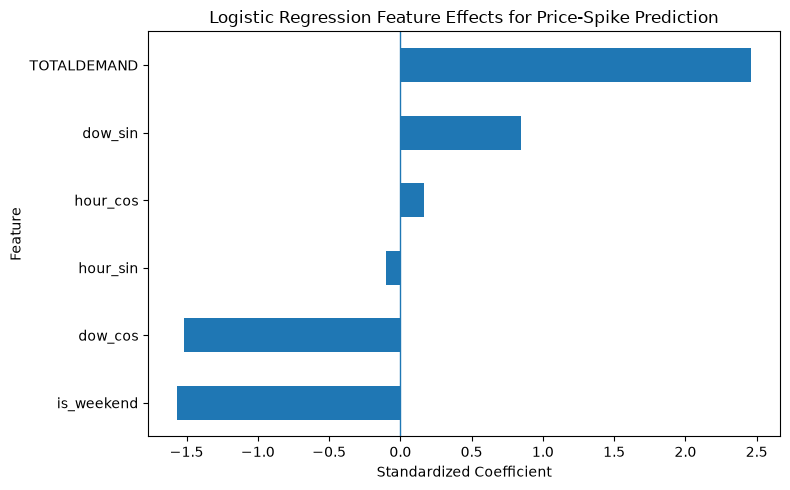

In [82]:
plt.figure(figsize=(8, 5))

standardized_coefficients.plot(kind="barh")

plt.axvline(0, linewidth=1)
plt.xlabel("Standardized Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Feature Effects for Price-Spike Prediction")

plt.tight_layout()
plt.show()

### Interpretation

The Logistic Regression coefficients provide insight into how the available predictors contribute to price-spike classification. Positive coefficients indicate that increases in a predictor are associated with higher predicted odds of a price spike, while negative coefficients indicate lower predicted odds, holding the other predictors constant.

The magnitude of the standardized coefficients provides an indication of the relative strength of each predictor within the fitted model. Electricity demand is particularly important because the exploratory analysis showed that price-spike rates increased substantially at higher demand levels.

The sine and cosine variables for hour and day of week should be interpreted jointly rather than individually, since each pair represents a cyclical time variable. Their contribution therefore supports the earlier exploratory finding that price-spike risk varies systematically across the day and week.

These coefficients describe predictive associations within the fitted Logistic Regression model and should not be interpreted as causal effects.

## 12. Limitations and Next Steps

The predictive models are deliberately based on a small set of demand and temporal features. This makes the analysis interpretable, but it also limits predictive performance.

Important variables not currently included include:

- renewable generation and generation mix;
- generator availability and outages;
- interconnector flows and network constraints;
- weather and temperature;
- bidding behaviour and dispatch conditions; and
- lagged demand and price information.

A further improvement would be to extend the dataset across multiple months or years and use **walk-forward / time-series cross-validation** rather than relying on a single train–test split.

Another useful extension would be to add **lag features**, such as RRP and demand from 5, 10, 15 and 30 minutes earlier, if the goal becomes true short-term forecasting rather than same-interval price estimation.